# Building a training dataset from an orthomosaic

Three inputs go in — an orthomosaic, a stem shapefile, an AOI polygon — and a
`train/` + `mask/` folder pair comes out, ready for `training.run_train`.

The whole thing is three steps, and the order matters:

| | step | why it must come here |
|---|---|---|
| 1 | **fix** the geometry | an invalid ring aborts GEOS mid-run, after hours of sampling |
| 2 | **sample** tiles | needs valid geometry to intersect against |
| 3 | **split** train/val/test | must be spatial; a random split of oversampled tiles leaks |

`scripts/make_splits.py` runs all three in that order for a whole corpus. This notebook
does one site by hand so the arithmetic in the middle is visible.

In [1]:
import shutil
import os, sys, math, json
sys.path.insert(0, "..")            # run from notebooks/

GIS = "/Users/christian/data/Winmol/training_data/WINMOL_Trainings_Data/GIS"
SITE = "20210706_EW_WW_Kaufland"     # beech, the finest-resolution beech ortho we have

ORTHO = f"{GIS}/Orthomosaics/beech/{SITE}_ortho.tif"
STEMS = f"{GIS}/Training_Data/{SITE}.shp"      # the digitised stem polygons
AOI   = f"{GIS}/Polygone/{SITE}_AOE.shp"       # the windthrow area actually surveyed
OUT   = os.path.expanduser("~/winmol_data/demo")

# sample_tiles APPENDS to tiles.jsonl -- start clean or the manifest
# ends up describing tiles from a previous run as well as this one
shutil.rmtree(OUT, ignore_errors=True)

for p in (ORTHO, STEMS, AOI):
    print(f"{'ok ' if os.path.exists(p) else 'MISSING'} {p}")

ok  /Users/christian/data/Winmol/training_data/WINMOL_Trainings_Data/GIS/Orthomosaics/beech/20210706_EW_WW_Kaufland_ortho.tif
ok  /Users/christian/data/Winmol/training_data/WINMOL_Trainings_Data/GIS/Training_Data/20210706_EW_WW_Kaufland.shp
ok  /Users/christian/data/Winmol/training_data/WINMOL_Trainings_Data/GIS/Polygone/20210706_EW_WW_Kaufland_AOE.shp


## What is actually on disk

Look before sampling. Two numbers decide everything downstream: the orthomosaic's ground
sample distance, and how much AOI survives the inward buffer.

In [2]:
import numpy as np
import fiona, rasterio
from shapely.geometry import shape
from shapely.ops import unary_union

with rasterio.open(ORTHO) as r:
    gsd, crs, wh = r.res[0], r.crs, (r.width, r.height)
with fiona.open(AOI) as c:
    aoi = unary_union([shape(f["geometry"]).buffer(0) for f in c])
with fiona.open(STEMS) as c:
    stems = [shape(f["geometry"]) for f in c]

print(f"ortho     {wh[0]} x {wh[1]} px, {gsd*100:.2f} cm/px, {crs}")
print(f"AOI       {aoi.area:,.0f} m²")
print(f"stems     {len(stems)} polygons, {sum(s.area for s in stems):,.0f} m² of stem")
print(f"invalid   {sum(not s.is_valid for s in stems)} polygons")

ortho     12678 x 9881 px, 2.09 cm/px, EPSG:25833
AOI       5,393 m²
stems     125 polygons, 250 m² of stem
invalid   6 polygons


## The scale arithmetic

A tile is a square of `extent_m` metres on the ground, resampled to `tile_px` pixels. So

> **effective GSD = `extent_m / tile_px`**

and this is the *only* thing the model ever sees — the orthomosaic's own resolution drops
out. Match it to how the Analyzer will serve the model: `ExecutionPlan.py:95-97` cuts
`ceil(tile_size / pixel_size)` source pixels and resizes to 512, giving
`tile_size / 512`. At the default `tile_size=15` that is **2.93 cm/px**.

Tiles are also rotated by a random angle, so the footprint must stay inside the AOI at
*any* rotation. That needs an inward buffer of the square's half-diagonal,
`extent_m · √2 / 2`. Anything less and tiles hang over the edge into undigitised ground,
where real stems count as false negatives.

In [3]:
print(f"{'extent':>7} {'tile':>6} {'eff GSD':>9} {'resample':>10} {'buffer':>7} {'usable AOI':>11}")
for extent_m in (10.24, 15.0, 20.0):
    tile_px = 512
    eff = extent_m / tile_px
    factor = (extent_m / gsd) / tile_px      # >1 downsamples, <1 upsamples
    buf = extent_m * math.sqrt(2) / 2
    usable = aoi.buffer(-buf).area
    tag = "DOWN" if factor > 1.02 else ("up" if factor < 0.98 else "1:1")
    print(f"{extent_m:7.2f} {tile_px:6d} {eff*100:8.2f}cm {factor:6.2f} {tag:<4}"
          f" {buf:6.2f}m {usable:10,.0f}m²")

 extent   tile   eff GSD   resample  buffer  usable AOI
  10.24    512     2.00cm   0.96 up     7.24m      3,100m²
  15.00    512     2.93cm   1.40 DOWN  10.61m      2,190m²
  20.00    512     3.91cm   1.87 DOWN  14.14m      1,412m²


Read that table before choosing `extent`. It tells you two things at once:

- **whether tiles are up- or downsampled.** Only downsampling loses information, and only
  downsampling makes anti-aliasing matter at all.
- **how much ground you actually get.** A larger extent needs a larger buffer, and on a
  small AOI the buffer can eat the site. That is why the native-1024 experiment was
  impossible on this corpus, not a bug.

## Step 1 — fix the geometry

`make_valid` on self-intersecting rings. Cheap, and it turns a mid-run GEOS abort into a
line of output. The corpus had 50 invalid polygons across 8 sites.

In [4]:
from scripts.fix_geometries import fix

os.makedirs(OUT, exist_ok=True)
STEMS_FIXED = f"{OUT}/{SITE}_fixed.shp"
rep = fix(STEMS, out_path=STEMS_FIXED, report_path=f"{OUT}/repairs.json", quiet=True)

# `entries` holds one record per repair; keep the summary here, it is in the JSON
{k: v for k, v in rep.items() if k not in ("entries", "dropped_entries")}

{'source': '/Users/christian/data/Winmol/training_data/WINMOL_Trainings_Data/GIS/Training_Data/20210706_EW_WW_Kaufland.shp',
 'polygons': 125,
 'invalid': 6,
 'repaired': 6,
 'dropped': 0,
 'area_delta_m2': -0.0588,
 'written': 125,
 'output': '/Users/christian/winmol_data/demo/20210706_EW_WW_Kaufland_fixed.shp'}

## Step 2 — sample tiles

For each attempt: draw a random point in the buffered AOI, pick a random angle, cut the
rotated square, rasterise the stems that fall inside it, and keep the tile only if the
*finished mask* carries at least `min_stem_frac` stem pixels.

Measuring the finished mask — rather than the polygons that intersect the footprint — is
deliberate. The original R script summed the **whole** area of every polygon touching the
footprint, so tiles qualified on stems lying mostly outside them. That single rule costs
8–27 F1 points.

In [5]:
from scripts.sample_training_tiles import sample_tiles

stats = sample_tiles(
    ortho=ORTHO, stems=STEMS_FIXED, aoi=AOI, out_dir=f"{OUT}/all",
    extent_m=10.24,        # -> 2.00 cm/px effective
    tile_px=512,
    oversample=25,         # attempts per footprint-sized cell; R used 100
    min_stem_frac=1/200,   # reject tiles with less stem than this
    seed=1,
    quiet=False,
)
stats

ortho 2.09 cm/px -> tiles 2.00 cm/px (upsample x1.05)
AOI 5393 m² -> 3100 m² after a 7.24 m inward buffer; 739 attempts at 25x oversampling


wrote 686 tiles to /Users/christian/winmol_data/demo/all (mean stem coverage 6.39%)
  provenance appended to tiles.jsonl
rejected: 5 empty, 48 below 0.50% stem, 0 over nodata


{'attempts': 739,
 'no_stem': 5,
 'too_few_stems': 48,
 'nodata': 0,
 'written': 686,
 'manifest': '/Users/christian/winmol_data/demo/all/tiles.jsonl',
 'site': '20210706_EW_WW_Kaufland',
 'mean_stem_coverage': 0.06393,
 'next_index': 687}

**Read the rejection counts, not just the written count.** A high `too_few_stems` means
the AOI is sparser than the floor assumes; a nonzero `nodata` means the footprint
is running off the imagery.

## Step 3 — split, spatially

**Never split these tiles randomly.** At 25× oversampling the footprints overlap heavily,
so a random split puts near-duplicate tiles on both sides and the validation score becomes
fiction.

Instead cut the AOI into blocks, assign whole blocks to splits, and sample each split
separately with the same `split_seed`. Re-run the cell below once per split.

In [6]:
for split in ("train", "val"):
    sample_tiles(
        ortho=ORTHO, stems=STEMS_FIXED, aoi=AOI, out_dir=f"{OUT}/{split}",
        extent_m=10.24, tile_px=512, oversample=25, seed=1,
        block_size_m=50,
        split=split,
        split_fractions={"train": 0.7, "val": 0.3, "test": 0.0},
        split_seed=1,          # identical across splits, or blocks land on both sides
        quiet=True,
    )
    n = len(os.listdir(f"{OUT}/{split}/train"))
    print(f"{split:6} {n:5d} tiles")

train    293 tiles


val       58 tiles


## Verify the split is leak-free — numerically

Do not assert this, measure it. Every dataset carries `tiles.jsonl` with each tile's world
centre, so the closest train↔val approach can be computed directly and compared against
the distance below which two footprints can overlap at all.
The threshold is not arbitrary and the margin is not luck: `_spatial_blocks`
shrinks *each block* by the footprint half-diagonal, so two centres either side of
a shared block edge are at least `2 × extent·√2/2 = extent·√2` apart — exactly the
distance at which two rotated squares can no longer share any area.


In [7]:
import itertools

def centres(split):
    with open(f"{OUT}/{split}/tiles.jsonl") as f:
        rows = [json.loads(l) for l in f]
    return [(r["centre_x"], r["centre_y"]) for r in rows], rows[0]["extent_m"]

tr, extent_m = centres("train")
va, _ = centres("val")

closest = min(math.dist(a, b) for a, b in itertools.product(tr, va))
threshold = extent_m * math.sqrt(2)          # two rotated squares can touch below this

print(f"closest train<->val centre distance : {closest:7.2f} m")
print(f"overlap threshold (extent * sqrt2)  : {threshold:7.2f} m")
print("LEAK-FREE" if closest > threshold else "*** TILES CAN OVERLAP — do not trust val ***")

closest train<->val centre distance :   15.07 m
overlap threshold (extent * sqrt2)  :   14.48 m
LEAK-FREE


### See the split on the ground

The distance check above is the proof; this is the picture behind it. Blocks are assigned
whole to a split, so train and val tile centres occupy disjoint regions with a visible
gap — the inward buffer — along every shared block edge.


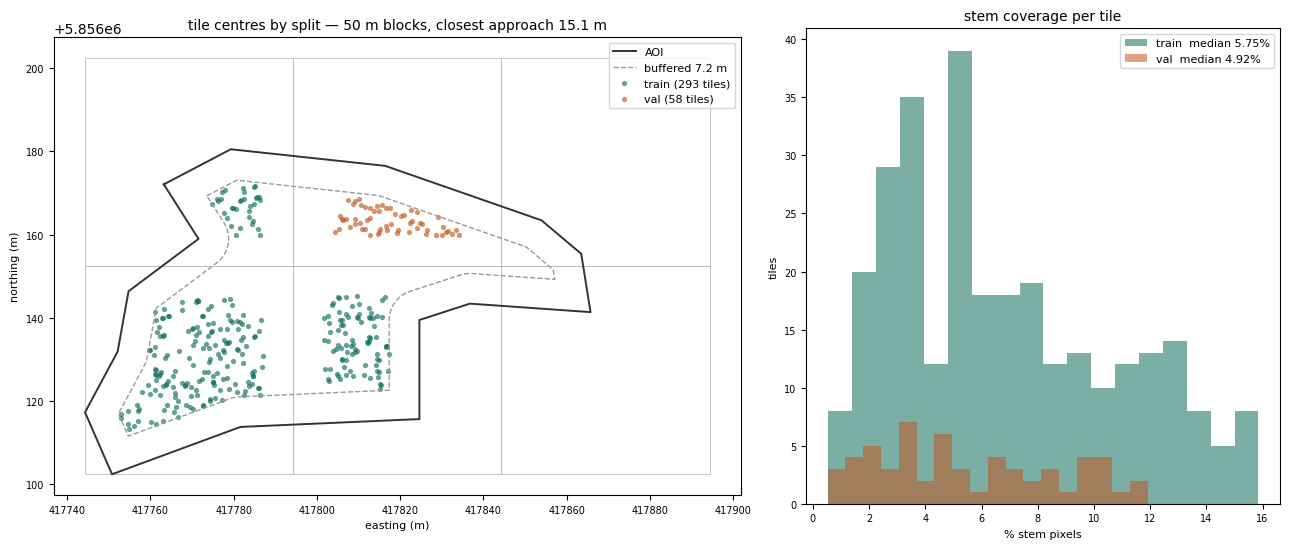

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

COL = {"train": "#0F6E5C", "val": "#C2571E"}
buf = extent_m * math.sqrt(2) / 2

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 5.6),
                              gridspec_kw={"width_ratios": [1.45, 1]})

# AOI outline, plus the inward buffer no tile centre may cross
for geom, style in ((aoi, dict(color="#333", lw=1.4, label="AOI")),
                    (aoi.buffer(-buf), dict(color="#999", lw=1.0, ls="--",
                                            label=f"buffered {buf:.1f} m"))):
    polys = getattr(geom, "geoms", [geom])
    for k, g in enumerate(polys):
        if g.is_empty: continue
        x, y = g.exterior.xy
        ax.plot(x, y, **(style if k == 0 else {k2: v for k2, v in style.items()
                                               if k2 != "label"}))

# the 50 m block grid the split was drawn on
minx, miny, maxx, maxy = aoi.bounds
bx = minx
while bx < maxx:
    by = miny
    while by < maxy:
        ax.add_patch(Rectangle((bx, by), 50, 50, fill=False,
                               ec="#BBB", lw=0.6, zorder=0))
        by += 50
    bx += 50

for split, pts in (("train", tr), ("val", va)):
    ax.scatter(*zip(*pts), s=14, c=COL[split], alpha=.65, lw=0,
               label=f"{split} ({len(pts)} tiles)")
ax.set_aspect("equal"); ax.legend(fontsize=8, loc="upper right")
ax.set_title(f"tile centres by split — 50 m blocks, closest approach {closest:.1f} m",
             fontsize=10)
ax.set_xlabel("easting (m)", fontsize=8); ax.set_ylabel("northing (m)", fontsize=8)
ax.tick_params(labelsize=7)

# a split is only usable if both sides carry comparable stem density
for split in ("train", "val"):
    rows = [json.loads(l) for l in open(f"{OUT}/{split}/tiles.jsonl")]
    frac = [r["stem_frac"] * 100 for r in rows]
    ax2.hist(frac, bins=18, alpha=.55, color=COL[split], lw=0,
             label=f"{split}  median {np.median(frac):.2f}%")
ax2.set_title("stem coverage per tile", fontsize=10)
ax2.set_xlabel("% stem pixels", fontsize=8); ax2.set_ylabel("tiles", fontsize=8)
ax2.legend(fontsize=8); ax2.tick_params(labelsize=7)
plt.tight_layout()

Two things to read off this. **Left:** train and val occupy different blocks, and the
closest centres are further apart than two footprints could ever overlap — that is the
split being leak-free, drawn rather than asserted. **Right:** if the two histograms sat in
different places, the validation set would be measuring a different problem from the
training set, and the checkpoint it selects would not be the one you want.


## Look at the tiles

A random sample, seed stated. Not the best ones — a selected figure misrepresents, and
mask misalignment is only ever caught by eye.

> **Masks are palette GIFs.** `np.asarray(Image.open(m))` returns palette *indices* —
> `[0, 1]` — not pixel values `[0, 255]`. Testing `> 127` on those reports every tile as
> 0.00% stem while the stems are plainly visible in the image. Always `.convert("L")`
> first, exactly as `training/dataset.py:70` does.


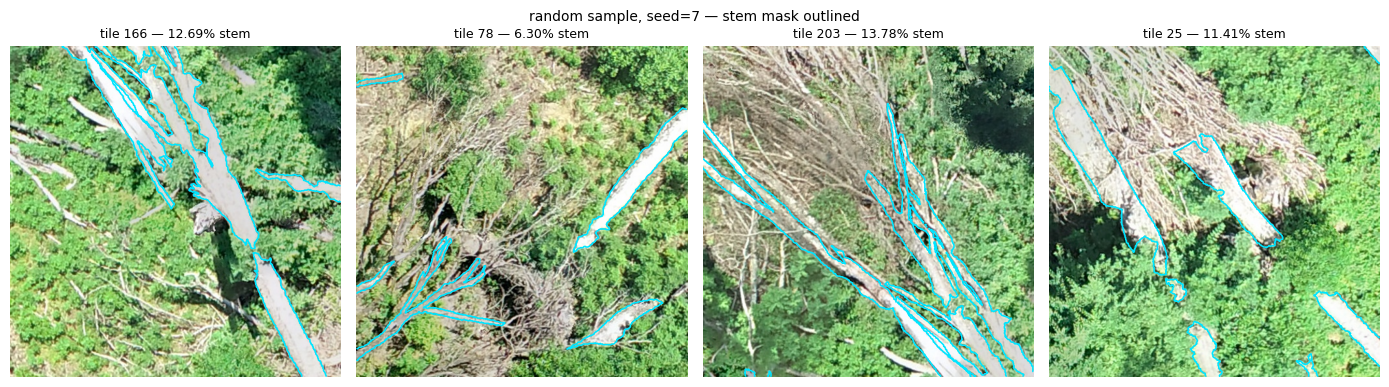

In [9]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def read_mask(path):
    """Masks are palette GIFs -- np.asarray() on one gives palette INDICES (0/1),
    not values (0/255), so a `> 127` test silently reports every tile as empty.
    convert('L') pushes the indices back through the palette. training/dataset.py
    does the same thing at line 70; anything reading these masks must."""
    return np.asarray(Image.open(path).convert("L")) > 127

random.seed(7)
n_tiles = len(os.listdir(f"{OUT}/train/train"))
ids = random.sample(range(1, n_tiles + 1), 4)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.9))
for ax, i in zip(axes, ids):
    rgb = np.asarray(Image.open(f"{OUT}/train/train/train{i}.jpeg"))
    msk = read_mask(f"{OUT}/train/mask/mask{i}.gif")
    ax.imshow(rgb)
    # outline, not fill: a fill hides the evidence you are checking
    ax.contour(msk, levels=[0.5], colors="#00E5FF", linewidths=1.1)
    ax.set_title(f"tile {i} — {msk.mean()*100:.2f}% stem", fontsize=9)
    ax.axis("off")
fig.suptitle("random sample, seed=7 — stem mask outlined", fontsize=10)
plt.tight_layout()

If a mask looks wrong, trace it back to the ground rather than guessing:

```bash
python scripts/locate_tile.py --data-dir ~/winmol_data/demo/train --tile 42 --crop out.png
```

That re-cuts the same footprint from the orthomosaic at native resolution, which usually
settles whether the label or the sampler is at fault.

## Train on it

```bash
python -m training.run_train --arch hrnet \
    --data-dir      ~/winmol_data/demo/train \
    --val-data-dir  ~/winmol_data/demo/val \
    --test-data-dir ~/winmol_data/demo/test \
    --epochs 30 --batch-size 16 --device cuda \
    --out-dir output/demo
```

`hrnet` at 16.1M from scratch is the strongest configuration measured on this corpus —
ahead of an 82M pretrained SegFormer and a 203M DINOv3 ConvNeXt. The run writes a
contract-conformant `model.onnx` the Analyzer can serve directly.

### For a real experiment, not a demo

- **Use several sites.** One site cannot tell segmentation quality from domain transfer;
  site identity has outweighed every other variable measured in this project.
- **Hold out a whole orthomosaic for test**, and check its validation signal is alive
  before trusting any checkpoint — a site that returns F1 0.0000 once voided six runs here.
- `scripts/make_splits.py --config … --strategy sites` does all of the above for a corpus.

---

## Scaling to the whole corpus

One site by hand is the demo. For a real model, `scripts/make_splits.py` runs
fix → sample → split over every site in a config, and offers three ways to divide the
ground:

| strategy | what it answers | when |
|---|---|---|
| `blocks` | how well can we read *these* forests | building a model; every site feeds every split |
| `halve` | same, coarser | very few sites, want one cut per site |
| `sites` | does this generalise to a *new* forest | ≥6 sites; the honest transfer number |

For a beech model the choice is `blocks`. Holding a whole orthomosaic out removes an
entire acquisition — its phenology, colour cast and ground resolution — and one of the
four beech sites (Bachsee_north, 100% amber November canopy) returns **F1 exactly 0.0000**
when held out. Blocks keep its colour domain in training where it helps, without letting
it void a fold.

```bash
python scripts/make_splits.py --config configs/beech_blocks.json \
    --out ~/winmol_data/BeechAll --strategy blocks
```

That takes a few minutes over four orthomosaics, so the cell below reads the result
rather than rebuilding it.

site                              train   val  test   closest
20171016_EW_WW_Campus              1000   200   200     14.8m
20171114_EW_WW_Bachsee_north       1000   200   200     15.1m
20210706_EW_WW_Kaufland              88    66    66     14.7m
20220226_EW_WW_Campus_Oberheide    1000   200   200     15.7m


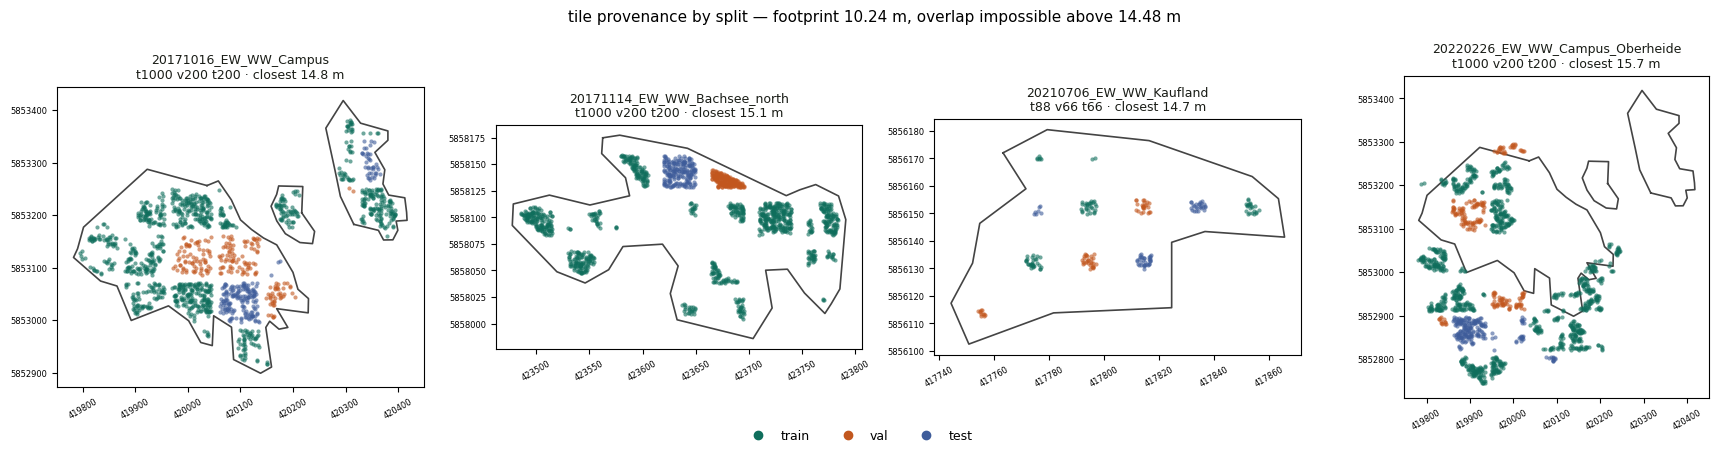

In [10]:
from scripts.plot_splits import plot, load

CORPUS = os.path.expanduser("~/winmol_data/BeechAll")

if not os.path.isdir(CORPUS):
    print("build it first:\n  python scripts/make_splits.py "
          "--config configs/beech_blocks.json --out ~/winmol_data/BeechAll "
          "--strategy blocks")
else:
    fig, summary = plot(CORPUS, "../configs/beech_blocks.json")
    print(f"{'site':32s} {'train':>6s} {'val':>5s} {'test':>5s} {'closest':>9s}")
    for name, counts, worst, missing in summary:
        print(f"{name:32s} {counts['train']:6d} {counts['val']:5d} "
              f"{counts['test']:5d} {worst:8.1f}m"
              + (f"  <- no {'/'.join(missing)}" if missing else ""))

Three things to read off that figure, in order of how badly each one bites:

1. **Colours must not interleave.** Blocks are dealt whole, so each split occupies
   distinct patches with a gap along every shared edge. Salt-and-pepper mixing means the
   split was drawn per *tile*, and at 100× oversampling that puts near-duplicates on both
   sides — validation then scores training data.
2. **Every site should show all three colours.** On the first build of this dataset
   Campus alone filled the whole 800-tile validation budget and the other three sites
   reached validation with nothing, because the cap was applied per site instead of
   being shared. Nothing in the tile counts revealed it; the picture did.
3. **Closest approach must clear `extent · √2`.** Above that distance two rotated
   footprints cannot share a pixel. Here it is 14.7–15.7 m against a 14.48 m floor.

Kaufland is the site to notice: 88 training tiles against 1,000 from each of the others.
Its AOI is 5,393 m², and 20 m blocks minus the 7.24 m buffer leave only small islands —
visible as the sparse clusters in its panel. It is also the *only* beech ortho fine enough
(2.09 cm/px) to be downsampled at the Analyzer's default scale, so the corpus can least
afford to under-sample exactly the site it cannot help under-sampling.

### What this split does and does not claim

The test tiles are spatially disjoint from training, so nothing leaks. They are **not**
site-disjoint, so the score says how well the model reads *these four forests* — not a new
one. Measured on a genuinely unseen orthomosaic the same architecture scores **0.7229**,
and that is the number to quote for deployment. Report both, never the friendlier one
alone.